# Ensemble Inference: Model-2

## Block 1. Imports, Configuration, and Ensemble Settings

In [1]:
# Block 1: Import libraries, define evaluation metrics, checkpoint names, and ensemble weights.
import os
import random
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.ndimage import binary_erosion, distance_transform_edt, zoom
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from skimage import measure


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODALITIES = ['flair', 't1', 't1ce', 't2']
REGION_NAMES = ['WT', 'TC', 'ET']
INPUT_CHANNELS = len(MODALITIES)
OUTPUT_CHANNELS = len(REGION_NAMES)

TRAIN_RATIO = 0.70
VALID_RATIO = 0.15
TEST_RATIO = 0.15

# Both trained models use the same 128 x 128 x 128 resized 3D input space.
INPUT_SIZE = (128, 128, 128)
CACHE_IMAGE_DTYPE = np.float32
CACHE_IMAGE_DTYPE_NAME = 'float32'

BASE_CHANNELS = 16
DROPOUT_RATE = 0.10
INFERENCE_BATCH_SIZE = 1
NUM_WORKERS = 0

# Checkpoint names produced by Paper_3_v6.ipynb and Paper_3_v6_patch.ipynb.
MAIN_CHECKPOINT_NAME = 'paper3_air_unet_no_att_dec1_dropout_dice_focal_adamw_affine_aug_best.pt'
PATCH_CHECKPOINT_NAME = 'paper3_air_unet_patch_best.pt'

# Fixed source rule for the ensemble.
# Main model stays dominant because it is full-volume consistent; patch model gives small TC/ET refinement.
ENSEMBLE_WEIGHTS = {
    'WT': {'main': 1.00, 'patch': 0.00},
    'TC': {'main': 0.85, 'patch': 0.15},
    'ET': {'main': 0.30, 'patch': 0.70},
}

# Keep these fixed so Block 8 only tunes thresholds, not source ratios.
PATCH_WEIGHT_SEARCH_VALUES = {
    'WT': [0.00],
    'TC': [0.15],
    'ET': [0.30],
}

# Thresholds are tuned on validation data together with the ensemble ratio.
PREDICTION_THRESHOLD = 0.50
THRESHOLD_SEARCH_VALUES = np.round(np.arange(0.30, 0.76, 0.01), 2)
ENSEMBLE_THRESHOLDS = {region_name: PREDICTION_THRESHOLD for region_name in REGION_NAMES}

# Evaluation metrics reported in this notebook.
EVALUATION_METRICS = ['dice', 'precision', 'sensitivity', 'specificity', 'hd95_voxels']

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print('Input size:', INPUT_SIZE)
print('Evaluation metrics:', EVALUATION_METRICS)
print('Ensemble weights:', ENSEMBLE_WEIGHTS)

/home/danishzaheer/miniconda3/envs/foundation_AI/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Input size: (128, 128, 128)
Evaluation metrics: ['dice', 'precision', 'sensitivity', 'specificity', 'hd95_voxels']
Ensemble weights: {'WT': {'main': 1.0, 'patch': 0.0}, 'TC': {'main': 0.85, 'patch': 0.15}, 'ET': {'main': 0.3, 'patch': 0.7}}


## Block 2. Locate Dataset, Cache, and Checkpoints

In [2]:
# Block 2: Locate project folders, raw BraTS data, resized cache, and trained checkpoints.
def find_project_root(start_path):
    start_path = Path(start_path).resolve()

    for folder in [start_path] + list(start_path.parents):
        if (folder / 'data').exists() and ((folder / 'Paper_3_v6.ipynb').exists() or (folder / 'Paper_3.ipynb').exists()):
            return folder

    return start_path


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / 'data'
PROCESSED_ROOT = DATA_ROOT / 'processed'
CHECKPOINT_ROOT = PROJECT_ROOT / 'checkpoints'
PREDICTION_ROOT = PROJECT_ROOT / 'predictions' / 'paper3_ensemble_3d_masks'
CACHE_ROOT = PROCESSED_ROOT / f'paper3_air_unet_resized_{INPUT_SIZE[0]}_{INPUT_SIZE[1]}_{INPUT_SIZE[2]}_{CACHE_IMAGE_DTYPE_NAME}'

training_root_candidates = [
    DATA_ROOT / 'brats2020' / 'BraTS2020_TrainingData' / 'MICCAI_BraTS2020_TrainingData',
    DATA_ROOT / 'raw' / 'BraTS2020_TrainingData' / 'MICCAI_BraTS2020_TrainingData',
]

TRAINING_ROOT = None
for candidate in training_root_candidates:
    if candidate.exists():
        TRAINING_ROOT = candidate.resolve()
        break

if TRAINING_ROOT is None:
    raise FileNotFoundError('Could not find BraTS2020_TrainingData in data/brats2020 or data/raw.')

MAIN_CHECKPOINT_PATH = CHECKPOINT_ROOT / MAIN_CHECKPOINT_NAME
PATCH_CHECKPOINT_PATH = CHECKPOINT_ROOT / PATCH_CHECKPOINT_NAME

if not MAIN_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f'Main checkpoint not found: {MAIN_CHECKPOINT_PATH}')
if not PATCH_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f'Patch checkpoint not found: {PATCH_CHECKPOINT_PATH}')

PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
PREDICTION_ROOT.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Training data:', TRAINING_ROOT)
print('Resized cache:', CACHE_ROOT)
print('Main checkpoint:', MAIN_CHECKPOINT_PATH)
print('Patch checkpoint:', PATCH_CHECKPOINT_PATH)
print('3D prediction output folder:', PREDICTION_ROOT)

Project root: /home/danishzaheer/Deep_learning_project
Training data: /home/danishzaheer/Deep_learning_project/data/raw/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Resized cache: /home/danishzaheer/Deep_learning_project/data/processed/paper3_air_unet_resized_128_128_128_float32
Main checkpoint: /home/danishzaheer/Deep_learning_project/checkpoints/paper3_air_unet_no_att_dec1_dropout_dice_focal_adamw_affine_aug_best.pt
Patch checkpoint: /home/danishzaheer/Deep_learning_project/checkpoints/paper3_air_unet_patch_best.pt
3D prediction output folder: /home/danishzaheer/Deep_learning_project/predictions/paper3_ensemble_3d_masks


## Block 3. Build the Same 70/15/15 Case Split

In [3]:
# Block 3: Find all labeled BraTS cases and reproduce the same patient-level 70/15/15 split.
def find_case_files(case_dir):
    case_id = case_dir.name
    file_paths = {'case_id': case_id, 'case_dir': str(case_dir)}

    for modality in MODALITIES:
        matches = sorted(case_dir.glob(f'*_{modality}.nii*'))
        if len(matches) == 0:
            return None
        file_paths[f'{modality}_path'] = str(matches[0])

    seg_matches = sorted(case_dir.glob('*_seg.nii*'))
    if len(seg_matches) == 0:
        return None
    file_paths['seg_path'] = str(seg_matches[0])
    return file_paths


case_rows = []
for case_dir in sorted(TRAINING_ROOT.glob('BraTS20_Training_*')):
    if case_dir.is_dir():
        row = find_case_files(case_dir)
        if row is not None:
            case_rows.append(row)

cases_df = pd.DataFrame(case_rows).sort_values('case_id').reset_index(drop=True)

case_ids = cases_df['case_id'].to_numpy().copy()
rng = np.random.default_rng(SEED)
rng.shuffle(case_ids)

num_cases = len(case_ids)
num_train = int(round(TRAIN_RATIO * num_cases))
num_valid = int(round(VALID_RATIO * num_cases))

train_ids = set(case_ids[:num_train])
valid_ids = set(case_ids[num_train:num_train + num_valid])
test_ids = set(case_ids[num_train + num_valid:])


def split_name(case_id):
    if case_id in train_ids:
        return 'train'
    if case_id in valid_ids:
        return 'valid'
    return 'test'


cases_df['split'] = cases_df['case_id'].apply(split_name)
train_df = cases_df[cases_df['split'] == 'train'].reset_index(drop=True)
valid_df = cases_df[cases_df['split'] == 'valid'].reset_index(drop=True)
test_df = cases_df[cases_df['split'] == 'test'].reset_index(drop=True)

print('Usable labeled cases:', len(cases_df))
print('Train cases:', len(train_df))
print('Validation cases:', len(valid_df))
print('Test cases:', len(test_df))
display(cases_df['split'].value_counts().rename_axis('split').reset_index(name='cases'))

Usable labeled cases: 368
Train cases: 258
Validation cases: 55
Test cases: 55


,split,cases
0,train,258
1,valid,55
2,test,55


## Block 4. Data Loading, Normalization, and Resized Cache

In [4]:
# Block 4: Load raw BraTS volumes, normalize each modality, convert labels to WT/TC/ET, and reuse/create resized cache.
def normalize_volume(volume):
    volume = volume.astype(np.float32)
    brain_pixels = volume > 0

    if brain_pixels.sum() == 0:
        return volume

    mean_value = volume[brain_pixels].mean()
    std_value = volume[brain_pixels].std()
    volume[brain_pixels] = (volume[brain_pixels] - mean_value) / (std_value + 1e-8)
    return volume


def create_region_masks(segmentation):
    wt = np.isin(segmentation, [1, 2, 4]).astype(np.float32)
    tc = np.isin(segmentation, [1, 4]).astype(np.float32)
    et = (segmentation == 4).astype(np.float32)
    return np.stack([wt, tc, et], axis=0)


def load_case(case_row):
    case_data = {}

    for modality in MODALITIES:
        volume = np.asanyarray(nib.load(case_row[f'{modality}_path']).dataobj).astype(np.float32)
        case_data[modality] = normalize_volume(volume)

    seg_image = nib.load(case_row['seg_path'])
    case_data['seg'] = np.asanyarray(seg_image.dataobj).astype(np.int16)
    case_data['spacing'] = seg_image.header.get_zooms()[:3]
    return case_data


def resize_volume(volume, target_shape, order):
    zoom_factors = [target / current for target, current in zip(target_shape, volume.shape)]
    return zoom(volume, zoom_factors, order=order).astype(np.float32)


def create_resized_sample(case_data):
    image_channels = []

    for modality in MODALITIES:
        resized_volume = resize_volume(case_data[modality], INPUT_SIZE, order=1)
        image_channels.append(resized_volume)

    resized_seg = resize_volume(case_data['seg'], INPUT_SIZE, order=0).astype(np.int16)
    mask = create_region_masks(resized_seg).astype(np.float32)
    image = np.stack(image_channels, axis=0).astype(np.float32)

    # Convert from C,H,W,D to C,D,H,W for PyTorch 3D convolution.
    image = np.transpose(image, (0, 3, 1, 2))
    mask = np.transpose(mask, (0, 3, 1, 2))
    return image, mask


def cached_case_folder(split_label, case_id):
    return CACHE_ROOT / split_label / case_id


def cached_case_files(split_label, case_id):
    folder = cached_case_folder(split_label, case_id)
    return folder / 'image.npy', folder / 'mask.npy'


def save_case_to_cache(row, split_label):
    image_path, mask_path = cached_case_files(split_label, row['case_id'])

    if image_path.exists() and mask_path.exists():
        return

    image_path.parent.mkdir(parents=True, exist_ok=True)
    case_data = load_case(row)
    image, mask = create_resized_sample(case_data)
    np.save(image_path, image.astype(CACHE_IMAGE_DTYPE))
    np.save(mask_path, mask.astype(np.uint8))


def prepare_cached_split(dataframe, split_label):
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc=f'Checking cache for {split_label}'):
        save_case_to_cache(row, split_label)
    print(f'{split_label} cached cases:', len(dataframe))


prepare_cached_split(train_df, 'train')
prepare_cached_split(valid_df, 'valid')
prepare_cached_split(test_df, 'test')

Checking cache for train: 100%|██████████| 258/258 [00:00<00:00, 15189.71it/s]


train cached cases: 258


Checking cache for valid: 100%|██████████| 55/55 [00:00<00:00, 14169.08it/s]


valid cached cases: 55


Checking cache for test: 100%|██████████| 55/55 [00:00<00:00, 15142.89it/s]

test cached cases: 55


## Block 5. Dataset and DataLoaders

In [5]:
# Block 5: Build inference-only datasets that return full 3D resized volumes, masks, and case IDs.
class BraTSCachedVolumeDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, split_label):
        self.dataframe = dataframe.reset_index(drop=True)
        self.split_label = split_label

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image_path, mask_path = cached_case_files(self.split_label, row['case_id'])

        image = np.load(image_path).astype(np.float32)
        mask = np.load(mask_path).astype(np.float32)
        return torch.from_numpy(image), torch.from_numpy(mask), row['case_id']


train_dataset = BraTSCachedVolumeDataset(train_df, 'train')
valid_dataset = BraTSCachedVolumeDataset(valid_df, 'valid')
test_dataset = BraTSCachedVolumeDataset(test_df, 'test')

loader_kwargs = {
    'batch_size': INFERENCE_BATCH_SIZE,
    'shuffle': False,
    'num_workers': NUM_WORKERS,
    'pin_memory': DEVICE.type == 'cuda',
}

train_loader = torch.utils.data.DataLoader(train_dataset, **loader_kwargs)
valid_loader = torch.utils.data.DataLoader(valid_dataset, **loader_kwargs)
test_loader = torch.utils.data.DataLoader(test_dataset, **loader_kwargs)

print('Train volumes:', len(train_dataset))
print('Validation volumes:', len(valid_dataset))
print('Test volumes:', len(test_dataset))

Train volumes: 258
Validation volumes: 55
Test volumes: 55


## Block 6. Model Architecture and Checkpoint Loading

In [6]:
# Block 6: Rebuild the AIR-UNet architecture and load the full-volume and patch checkpoints.
class InceptionResidualBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        branch_channels = out_channels // 4

        self.branch1 = nn.Sequential(
            nn.Conv3d(in_channels, branch_channels, kernel_size=1, bias=False),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True),
        )

        self.branch3 = nn.Sequential(
            nn.Conv3d(in_channels, branch_channels, kernel_size=1, bias=False),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(branch_channels, branch_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True),
        )

        self.branch5 = nn.Sequential(
            nn.Conv3d(in_channels, branch_channels, kernel_size=1, bias=False),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(branch_channels, branch_channels, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True),
        )

        self.branch_pool = nn.Sequential(
            nn.MaxPool3d(kernel_size=3, stride=1, padding=1),
            nn.Conv3d(in_channels, branch_channels, kernel_size=1, bias=False),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True),
        )

        self.fuse = nn.Sequential(
            nn.Conv3d(out_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm3d(out_channels),
        )

        self.shortcut = nn.Identity()
        if in_channels != out_channels:
            self.shortcut = nn.Conv3d(in_channels, out_channels, kernel_size=1, bias=False)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        b1 = self.branch1(x)
        b3 = self.branch3(x)
        b5 = self.branch5(x)
        bp = self.branch_pool(x)
        combined = torch.cat([b1, b3, b5, bp], dim=1)
        combined = self.fuse(combined)
        return self.relu(combined + self.shortcut(x))


class AttentionGate3D(nn.Module):
    def __init__(self, gate_channels, skip_channels, mid_channels):
        super().__init__()
        self.gate_conv = nn.Conv3d(gate_channels, mid_channels, kernel_size=1, bias=False)
        self.skip_conv = nn.Conv3d(skip_channels, mid_channels, kernel_size=1, bias=False)
        self.psi = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Conv3d(mid_channels, 1, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, gate, skip):
        gate_features = self.gate_conv(gate)
        skip_features = self.skip_conv(skip)

        if gate_features.shape[-3:] != skip_features.shape[-3:]:
            gate_features = F.interpolate(gate_features, size=skip_features.shape[-3:], mode='trilinear', align_corners=False)

        attention = self.psi(gate_features + skip_features)
        return skip * attention


class DecoderBlock3D(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose3d(in_channels, out_channels, kernel_size=2, stride=2)
        self.attention = AttentionGate3D(out_channels, skip_channels, out_channels // 2)
        self.block = InceptionResidualBlock3D(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape[-3:] != skip.shape[-3:]:
            x = F.interpolate(x, size=skip.shape[-3:], mode='trilinear', align_corners=False)

        skip = self.attention(x, skip)
        x = torch.cat([skip, x], dim=1)
        return self.block(x)


class PlainDecoderBlock3D(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose3d(in_channels, out_channels, kernel_size=2, stride=2)
        self.block = InceptionResidualBlock3D(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape[-3:] != skip.shape[-3:]:
            x = F.interpolate(x, size=skip.shape[-3:], mode='trilinear', align_corners=False)

        x = torch.cat([skip, x], dim=1)
        return self.block(x)


class AIRUNet3D(nn.Module):
    def __init__(self, input_channels=4, output_channels=3, base_channels=16):
        super().__init__()
        self.pool = nn.MaxPool3d(2)
        self.dropout = nn.Dropout3d(p=DROPOUT_RATE)

        self.enc1 = InceptionResidualBlock3D(input_channels, base_channels)
        self.enc2 = InceptionResidualBlock3D(base_channels, base_channels * 2)
        self.enc3 = InceptionResidualBlock3D(base_channels * 2, base_channels * 4)
        self.enc4 = InceptionResidualBlock3D(base_channels * 4, base_channels * 8)
        self.bottleneck = InceptionResidualBlock3D(base_channels * 8, base_channels * 16)

        self.dec4 = DecoderBlock3D(base_channels * 16, base_channels * 8, base_channels * 8)
        self.dec3 = DecoderBlock3D(base_channels * 8, base_channels * 4, base_channels * 4)
        self.dec2 = DecoderBlock3D(base_channels * 4, base_channels * 2, base_channels * 2)
        self.dec1 = PlainDecoderBlock3D(base_channels * 2, base_channels, base_channels)
        self.output = nn.Conv3d(base_channels, output_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))
        x3 = self.enc3(self.pool(x2))
        x4 = self.dropout(self.enc4(self.pool(x3)))
        b = self.dropout(self.bottleneck(self.pool(x4)))
        d4 = self.dropout(self.dec4(b, x4))
        d3 = self.dropout(self.dec3(d4, x3))
        d2 = self.dec2(d3, x2)
        d1 = self.dec1(d2, x1)
        return self.output(d1)


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def load_model_from_checkpoint(checkpoint_path):
    model = AIRUNet3D(INPUT_CHANNELS, OUTPUT_CHANNELS, base_channels=BASE_CHANNELS).to(DEVICE)
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    return model, checkpoint


main_model, main_checkpoint = load_model_from_checkpoint(MAIN_CHECKPOINT_PATH)
patch_model, patch_checkpoint = load_model_from_checkpoint(PATCH_CHECKPOINT_PATH)

print('Main model parameters:', f'{count_parameters(main_model):,}')
print('Patch model parameters:', f'{count_parameters(patch_model):,}')
print('Main checkpoint epoch:', main_checkpoint.get('epoch', 'unknown'))
print('Patch checkpoint epoch:', patch_checkpoint.get('epoch', 'unknown'))

/tmp/ipykernel_1954822/2467896822.py:152: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=DEVICE)


Main model parameters: 1,693,046
Patch model parameters: 1,693,046
Main checkpoint epoch: 42
Patch checkpoint epoch: 7


## Block 7. Ensemble Prediction and Evaluation Metrics

In [7]:
# Block 7: Define combined prediction, validation weight tuning, thresholding, and evaluation metrics.
def move_images_to_device(images):
    return images.to(DEVICE, non_blocking=True).float()


@torch.no_grad()
def get_main_and_patch_probabilities(images):
    images = move_images_to_device(images)
    main_probs = torch.sigmoid(main_model(images))
    patch_probs = torch.sigmoid(patch_model(images))
    return main_probs, patch_probs


@torch.no_grad()
def get_ensemble_probabilities(images):
    main_probs, patch_probs = get_main_and_patch_probabilities(images)

    combined_channels = []
    for region_index, region_name in enumerate(REGION_NAMES):
        weights = ENSEMBLE_WEIGHTS[region_name]
        combined_region = weights['main'] * main_probs[:, region_index] + weights['patch'] * patch_probs[:, region_index]
        combined_channels.append(combined_region)

    return torch.stack(combined_channels, dim=1)


def apply_hierarchical_postprocessing(predictions):
    predictions = predictions.bool().clone()
    wt_index = REGION_NAMES.index('WT')
    tc_index = REGION_NAMES.index('TC')
    et_index = REGION_NAMES.index('ET')

    predictions[:, tc_index] = predictions[:, tc_index] & predictions[:, wt_index]
    predictions[:, et_index] = predictions[:, et_index] & predictions[:, tc_index]
    return predictions


def threshold_probabilities(probabilities, region_thresholds):
    prediction_channels = []

    for region_index, region_name in enumerate(REGION_NAMES):
        threshold = region_thresholds.get(region_name, PREDICTION_THRESHOLD)
        prediction_channels.append(probabilities[:, region_index] >= threshold)

    predictions = torch.stack(prediction_channels, dim=1)
    return apply_hierarchical_postprocessing(predictions)


def safe_divide(numerator, denominator):
    if denominator == 0:
        return 1.0 if numerator == 0 else 0.0
    return numerator / denominator


def empty_counts():
    return {'tp': 0, 'fp': 0, 'tn': 0, 'fn': 0}


def update_binary_counts(counts, predictions, targets):
    predictions = predictions.bool()
    targets = targets.bool()

    counts['tp'] += int((predictions & targets).sum().item())
    counts['fp'] += int((predictions & ~targets).sum().item())
    counts['tn'] += int((~predictions & ~targets).sum().item())
    counts['fn'] += int((~predictions & targets).sum().item())


def calculate_metrics_from_counts(region_name, counts, split_label):
    tp, fp, tn, fn = counts['tp'], counts['fp'], counts['tn'], counts['fn']
    return {
        'split': split_label,
        'region': region_name,
        'dice': safe_divide(2 * tp, 2 * tp + fp + fn),
        'precision': safe_divide(tp, tp + fp),
        'sensitivity': safe_divide(tp, tp + fn),
        'specificity': safe_divide(tn, tn + fp),
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn,
    }


def crop_to_foreground(prediction, target, margin=2):
    union = prediction | target

    if not union.any():
        return prediction, target

    crop_slices = []
    for axis_coordinates, axis_size in zip(np.where(union), union.shape):
        start = max(int(axis_coordinates.min()) - margin, 0)
        end = min(int(axis_coordinates.max()) + margin + 1, axis_size)
        crop_slices.append(slice(start, end))

    crop_slices = tuple(crop_slices)
    return prediction[crop_slices], target[crop_slices]


def get_surface(mask):
    if not mask.any():
        return mask
    eroded = binary_erosion(mask, structure=np.ones((3, 3, 3)), border_value=0)
    return mask ^ eroded


def calculate_hd95(prediction, target):
    prediction = prediction.astype(bool)
    target = target.astype(bool)

    if not prediction.any() and not target.any():
        return 0.0

    if not prediction.any() or not target.any():
        return float(np.linalg.norm(prediction.shape))

    prediction, target = crop_to_foreground(prediction, target)
    prediction_surface = get_surface(prediction)
    target_surface = get_surface(target)

    distance_to_target = distance_transform_edt(~target_surface)
    distance_to_prediction = distance_transform_edt(~prediction_surface)

    prediction_to_target = distance_to_target[prediction_surface]
    target_to_prediction = distance_to_prediction[target_surface]
    all_surface_distances = np.concatenate([prediction_to_target, target_to_prediction])
    return float(np.percentile(all_surface_distances, 95))


def collect_validation_probabilities(data_loader):
    # Store validation probabilities once so ratio/threshold tuning does not rerun both models repeatedly.
    cached_batches = []

    for images, masks, case_ids in tqdm(data_loader, desc='Caching validation probabilities'):
        main_probs, patch_probs = get_main_and_patch_probabilities(images)
        cached_batches.append({
            'main_probs': main_probs.detach().cpu(),
            'patch_probs': patch_probs.detach().cpu(),
            'masks': masks.float().cpu(),
            'case_ids': list(case_ids),
        })

    return cached_batches


def tune_ensemble_weights_and_thresholds_on_validation(data_loader, patch_weight_search_values, threshold_values):
    validation_batches = collect_validation_probabilities(data_loader)
    threshold_values = [float(value) for value in threshold_values]

    search_rows = []
    selected_weights = {}
    selected_thresholds = {}

    for region_index, region_name in enumerate(REGION_NAMES):
        best_row = None

        for patch_weight in patch_weight_search_values[region_name]:
            main_weight = 1.0 - float(patch_weight)

            for threshold in threshold_values:
                counts = empty_counts()

                for batch in validation_batches:
                    region_probabilities = (
                        main_weight * batch['main_probs'][:, region_index]
                        + float(patch_weight) * batch['patch_probs'][:, region_index]
                    )
                    predictions = region_probabilities >= threshold
                    targets = batch['masks'][:, region_index] >= 0.5
                    update_binary_counts(counts, predictions, targets)

                row = calculate_metrics_from_counts(region_name, counts, 'valid')
                row['main_weight'] = main_weight
                row['patch_weight'] = float(patch_weight)
                row['threshold'] = threshold
                search_rows.append(row)

                if best_row is None or row['dice'] > best_row['dice']:
                    best_row = row

        selected_weights[region_name] = {
            'main': float(best_row['main_weight']),
            'patch': float(best_row['patch_weight']),
        }
        selected_thresholds[region_name] = float(best_row['threshold'])

    return selected_weights, selected_thresholds, pd.DataFrame(search_rows)


def evaluate_ensemble_loader(data_loader, split_label, region_thresholds):
    metric_counts = {region_name: empty_counts() for region_name in REGION_NAMES}
    hd95_values = {region_name: [] for region_name in REGION_NAMES}

    for images, masks, _case_ids in tqdm(data_loader, desc=f'Evaluating ensemble on {split_label}'):
        masks = masks.float()
        probabilities = get_ensemble_probabilities(images).cpu()
        predictions = threshold_probabilities(probabilities, region_thresholds).cpu()

        for region_index, region_name in enumerate(REGION_NAMES):
            region_predictions = predictions[:, region_index]
            region_targets = masks[:, region_index] >= 0.5
            update_binary_counts(metric_counts[region_name], region_predictions, region_targets)

            predictions_np = region_predictions.numpy()
            targets_np = region_targets.numpy()
            for case_index in range(predictions_np.shape[0]):
                hd95_values[region_name].append(calculate_hd95(predictions_np[case_index], targets_np[case_index]))

    rows = []
    for region_name in REGION_NAMES:
        row = calculate_metrics_from_counts(region_name, metric_counts[region_name], split_label)
        row['hd95_voxels'] = float(np.mean(hd95_values[region_name]))
        rows.append(row)

    return pd.DataFrame(rows)

## Block 8. Tune Ensemble Thresholds and Evaluate Train/Validation/Test

In [8]:
# Block 8: Use the fixed main/patch source rule, tune thresholds on validation, then report train/valid/test metrics.
ENSEMBLE_WEIGHTS, ENSEMBLE_THRESHOLDS, ensemble_search_df = tune_ensemble_weights_and_thresholds_on_validation(
    valid_loader,
    PATCH_WEIGHT_SEARCH_VALUES,
    THRESHOLD_SEARCH_VALUES,
)

print('Fixed ensemble weights used for prediction:')
for region_name in REGION_NAMES:
    print(region_name, ENSEMBLE_WEIGHTS[region_name])

print('\nBest ensemble thresholds selected on validation Dice:')
for region_name in REGION_NAMES:
    print(region_name, ENSEMBLE_THRESHOLDS[region_name])

best_search_rows = (
    ensemble_search_df.sort_values('dice', ascending=False)
    .groupby('region', as_index=False)
    .head(1)
    [['region', 'dice', 'main_weight', 'patch_weight', 'threshold', 'precision', 'sensitivity', 'specificity']]
    .sort_values('region')
)
display(best_search_rows)

train_metrics_df = evaluate_ensemble_loader(train_loader, 'train', ENSEMBLE_THRESHOLDS)
valid_metrics_df = evaluate_ensemble_loader(valid_loader, 'valid', ENSEMBLE_THRESHOLDS)
test_metrics_df = evaluate_ensemble_loader(test_loader, 'test', ENSEMBLE_THRESHOLDS)

ensemble_metrics_df = pd.concat([train_metrics_df, valid_metrics_df, test_metrics_df], ignore_index=True)
final_columns = ['split', 'region', 'dice', 'precision', 'sensitivity', 'specificity', 'hd95_voxels']
final_ensemble_metrics_df = ensemble_metrics_df[final_columns]

display(final_ensemble_metrics_df)

metrics_output_path = PREDICTION_ROOT / 'ensemble_metrics_train_valid_test.csv'
search_output_path = PREDICTION_ROOT / 'ensemble_weight_threshold_search_valid.csv'
final_ensemble_metrics_df.to_csv(metrics_output_path, index=False)
ensemble_search_df.to_csv(search_output_path, index=False)
print('Saved metrics:', metrics_output_path)
print('Saved validation search:', search_output_path)
print('Metrics are computed in resized 128 x 128 x 128 evaluation space.')
print('Final prediction still enforces hierarchy: ET inside TC, TC inside WT.')

Caching validation probabilities: 100%|██████████| 55/55 [01:25<00:00,  1.56s/it]


Fixed ensemble weights used for prediction:
WT {'main': 1.0, 'patch': 0.0}
TC {'main': 0.85, 'patch': 0.15}
ET {'main': 0.7, 'patch': 0.3}

Best ensemble thresholds selected on validation Dice:
WT 0.51
TC 0.54
ET 0.42


,region,dice,main_weight,patch_weight,threshold,precision,sensitivity,specificity
104,ET,0.850790,0.70,0.30,0.42,0.845134,0.856521,0.999620
70,TC,0.877443,0.85,0.15,0.54,0.884991,0.870023,0.999424
21,WT,0.912059,1.00,0.00,0.51,0.919040,0.905183,0.999094


Evaluating ensemble on test: 100%|██████████| 55/55 [00:25<00:00,  2.19it/s]


,split,region,dice,precision,sensitivity,specificity,hd95_voxels
0,train,WT,0.914421,0.920030,0.908881,0.999118,2.466605
1,train,TC,0.872594,0.887520,0.858163,0.999499,2.457802
2,train,ET,0.858739,0.833762,0.885259,0.999620,18.428269
3,valid,WT,0.912059,0.919040,0.905183,0.999094,2.811418
4,valid,TC,0.877344,0.885198,0.869628,0.999425,7.071428
5,valid,ET,0.849531,0.855875,0.843281,0.999656,14.370828
6,test,WT,0.901620,0.923771,0.880507,0.999201,3.002358
7,test,TC,0.844314,0.880724,0.810795,0.999515,2.880270
8,test,ET,0.834381,0.776691,0.901328,0.999464,14.260752


Saved metrics: /home/danishzaheer/Deep_learning_project/predictions/paper3_ensemble_3d_masks/ensemble_metrics_train_valid_test.csv
Saved validation search: /home/danishzaheer/Deep_learning_project/predictions/paper3_ensemble_3d_masks/ensemble_weight_threshold_search_valid.csv
Metrics are computed in resized 128 x 128 x 128 evaluation space.
Final prediction still enforces hierarchy: ET inside TC, TC inside WT.


## Block 9. Predict One Full 3D Case and Save Mask Volumes

In [9]:
# Block 9: Helper functions to produce and save one full 3D ensemble prediction mask.
def load_cached_case_by_index(dataframe, split_label, index):
    row = dataframe.iloc[index]
    image_path, mask_path = cached_case_files(split_label, row['case_id'])
    image = np.load(image_path).astype(np.float32)
    mask = np.load(mask_path).astype(np.float32)
    return row, image, mask


@torch.no_grad()
def predict_ensemble_case(image):
    image_tensor = torch.from_numpy(image).unsqueeze(0)
    probabilities = get_ensemble_probabilities(image_tensor).cpu()
    prediction = threshold_probabilities(probabilities, ENSEMBLE_THRESHOLDS).cpu()[0].numpy().astype(np.uint8)
    return probabilities[0].numpy().astype(np.float32), prediction


def region_masks_to_brats_label_map(region_masks):
    # region_masks shape is C,D,H,W. Output label map is D,H,W using BraTS labels: 1, 2, 4.
    wt = region_masks[REGION_NAMES.index('WT')].astype(bool)
    tc = region_masks[REGION_NAMES.index('TC')].astype(bool)
    et = region_masks[REGION_NAMES.index('ET')].astype(bool)

    label_map = np.zeros(wt.shape, dtype=np.uint8)
    label_map[wt & ~tc] = 2
    label_map[tc & ~et] = 1
    label_map[et] = 4
    return label_map


def save_prediction_case(split_label, case_id, prediction_masks, target_masks=None):
    split_folder = PREDICTION_ROOT / split_label
    split_folder.mkdir(parents=True, exist_ok=True)

    prediction_label_map = region_masks_to_brats_label_map(prediction_masks)
    prediction_path = split_folder / f'{case_id}_ensemble_prediction_128.nii.gz'
    nib.save(nib.Nifti1Image(prediction_label_map, affine=np.eye(4)), prediction_path)

    if target_masks is not None:
        target_label_map = region_masks_to_brats_label_map(target_masks)
        target_path = split_folder / f'{case_id}_ground_truth_128.nii.gz'
        nib.save(nib.Nifti1Image(target_label_map, affine=np.eye(4)), target_path)
    else:
        target_path = None

    return prediction_path, target_path


def predict_and_save_case(dataframe, split_label, index):
    row, image, target_masks = load_cached_case_by_index(dataframe, split_label, index)
    probabilities, prediction_masks = predict_ensemble_case(image)
    prediction_path, target_path = save_prediction_case(split_label, row['case_id'], prediction_masks, target_masks.astype(np.uint8))

    print('Case:', row['case_id'])
    print('Prediction saved:', prediction_path)
    print('Ground truth saved:', target_path)
    return row, image, target_masks, probabilities, prediction_masks

## Block 10. Brain Image Overlay and 3D Mask Visualization Helpers


In [10]:
# Block 10: Make paper-style brain-image overlays and optional 3D mask surfaces.
def normalize_slice_for_display(image_slice):
    image_slice = image_slice.astype(np.float32)
    brain_pixels = image_slice[image_slice != 0]

    if brain_pixels.size == 0:
        return np.zeros_like(image_slice, dtype=np.float32)

    low, high = np.percentile(brain_pixels, [1, 99])
    normalized = (image_slice - low) / (high - low + 1e-8)
    return np.clip(normalized, 0, 1)


def make_overlay_rgb(image_slice, ground_truth_mask, prediction_mask, alpha=0.55):
    gray = normalize_slice_for_display(image_slice)
    rgb = np.stack([gray, gray, gray], axis=-1)

    gt = ground_truth_mask.astype(bool)
    pred = prediction_mask.astype(bool)
    gt_only = gt & ~pred
    pred_only = pred & ~gt
    overlap = gt & pred

    colors = {
        'gt_only': np.array([0.00, 0.85, 0.20], dtype=np.float32),
        'pred_only': np.array([1.00, 0.10, 0.10], dtype=np.float32),
        'overlap': np.array([1.00, 0.90, 0.00], dtype=np.float32),
    }

    for mask, color in [(gt_only, colors['gt_only']), (pred_only, colors['pred_only']), (overlap, colors['overlap'])]:
        rgb[mask] = (1 - alpha) * rgb[mask] + alpha * color

    return rgb


def choose_best_slice(target_masks, prediction_masks, region_index):
    union = (target_masks[region_index] >= 0.5) | (prediction_masks[region_index] >= 0.5)

    if not union.any():
        return union.shape[0] // 2

    return int(np.argmax(union.sum(axis=(1, 2))))


def plot_brain_overlay_figure(image, target_masks, prediction_masks, case_id, split_label, save=True):
    # image is C,D,H,W. FLAIR is used as the background because tumor/edema contrast is usually clearest.
    flair_volume = image[MODALITIES.index('flair')]

    fig, axes = plt.subplots(len(REGION_NAMES), 3, figsize=(13, 12))
    if len(REGION_NAMES) == 1:
        axes = np.expand_dims(axes, axis=0)

    for region_index, region_name in enumerate(REGION_NAMES):
        slice_index = choose_best_slice(target_masks, prediction_masks, region_index)
        flair_slice = flair_volume[slice_index]
        gt_slice = target_masks[region_index, slice_index] >= 0.5
        pred_slice = prediction_masks[region_index, slice_index] >= 0.5

        gt_overlay = make_overlay_rgb(flair_slice, gt_slice, np.zeros_like(pred_slice), alpha=0.55)
        pred_overlay = make_overlay_rgb(flair_slice, np.zeros_like(gt_slice), pred_slice, alpha=0.55)
        combined_overlay = make_overlay_rgb(flair_slice, gt_slice, pred_slice, alpha=0.55)

        axes[region_index, 0].imshow(gt_overlay)
        axes[region_index, 0].set_title(f'{region_name} ground truth')

        axes[region_index, 1].imshow(pred_overlay)
        axes[region_index, 1].set_title(f'{region_name} prediction')

        axes[region_index, 2].imshow(combined_overlay)
        axes[region_index, 2].set_title(f'{region_name} GT + prediction | slice {slice_index}')

        for column_index in range(3):
            axes[region_index, column_index].axis('off')

    fig.suptitle(f'{split_label} case {case_id}: FLAIR with WT/TC/ET overlays', fontsize=15)
    fig.text(0.18, 0.02, 'Green = GT only', color='green', fontsize=12)
    fig.text(0.43, 0.02, 'Red = prediction only', color='red', fontsize=12)
    fig.text(0.70, 0.02, 'Yellow = overlap', color='#b8860b', fontsize=12)
    plt.tight_layout(rect=[0, 0.04, 1, 0.96])

    if save:
        output_path = PREDICTION_ROOT / split_label / f'{case_id}_paper_overlay.png'
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=300, bbox_inches='tight')
        print('Saved paper overlay figure:', output_path)

    plt.show()


def downsample_mask_for_plot(mask, factor=2):
    if factor <= 1:
        return mask.astype(bool)
    return mask.astype(bool)[::factor, ::factor, ::factor]


def add_mask_to_axis(ax, mask, color, label, alpha=0.35, max_scatter_points=12000):
    mask = mask.astype(bool)

    if not mask.any():
        ax.text2D(0.05, 0.95, f'{label}: empty', transform=ax.transAxes)
        return

    if measure is not None:
        verts, faces, _normals, _values = measure.marching_cubes(mask.astype(np.float32), level=0.5, step_size=2)
        verts = verts[:, [2, 1, 0]]
        mesh = Poly3DCollection(verts[faces], alpha=alpha)
        mesh.set_facecolor(color)
        mesh.set_edgecolor('none')
        mesh.set_label(label)
        ax.add_collection3d(mesh)
    else:
        coords = np.argwhere(mask)
        if coords.shape[0] > max_scatter_points:
            selected = np.random.choice(coords.shape[0], size=max_scatter_points, replace=False)
            coords = coords[selected]
        ax.scatter(coords[:, 2], coords[:, 1], coords[:, 0], c=[color], s=1, alpha=alpha, label=label)


def plot_3d_region_comparison(target_masks, prediction_masks, case_id, split_label, plot_downsample_factor=2):
    colors = {
        'ground_truth': '#2a9d8f',
        'prediction': '#e63946',
    }

    fig = plt.figure(figsize=(18, 6))
    for region_index, region_name in enumerate(REGION_NAMES):
        ax = fig.add_subplot(1, 3, region_index + 1, projection='3d')
        gt_mask = downsample_mask_for_plot(target_masks[region_index], factor=plot_downsample_factor)
        pred_mask = downsample_mask_for_plot(prediction_masks[region_index], factor=plot_downsample_factor)

        add_mask_to_axis(ax, gt_mask, colors['ground_truth'], 'ground truth', alpha=0.28)
        add_mask_to_axis(ax, pred_mask, colors['prediction'], 'prediction', alpha=0.35)

        ax.set_title(f'{split_label} | {case_id} | {region_name}')
        ax.set_xlim(0, gt_mask.shape[2])
        ax.set_ylim(0, gt_mask.shape[1])
        ax.set_zlim(0, gt_mask.shape[0])
        ax.set_xlabel('W')
        ax.set_ylabel('H')
        ax.set_zlabel('D')
        ax.view_init(elev=25, azim=35)

    handles = [
        plt.Line2D([0], [0], color=colors['ground_truth'], lw=6, label='ground truth'),
        plt.Line2D([0], [0], color=colors['prediction'], lw=6, label='prediction'),
    ]
    fig.legend(handles=handles, loc='upper center', ncol=2)
    plt.tight_layout()
    plt.show()


def summarize_case_region_scores(target_masks, prediction_masks):
    rows = []
    for region_index, region_name in enumerate(REGION_NAMES):
        counts = empty_counts()
        update_binary_counts(
            counts,
            torch.from_numpy(prediction_masks[region_index]).bool(),
            torch.from_numpy(target_masks[region_index] >= 0.5).bool(),
        )
        row = calculate_metrics_from_counts(region_name, counts, 'case')
        row['hd95_voxels'] = calculate_hd95(prediction_masks[region_index], target_masks[region_index] >= 0.5)
        rows.append(row)
    return pd.DataFrame(rows)[['region', 'dice', 'precision', 'sensitivity', 'specificity', 'hd95_voxels']]

## Block 11. Train Case Brain Overlay and 3D Mask Prediction


Case: BraTS20_Training_001
Prediction saved: /home/danishzaheer/Deep_learning_project/predictions/paper3_ensemble_3d_masks/train/BraTS20_Training_001_ensemble_prediction_128.nii.gz
Ground truth saved: /home/danishzaheer/Deep_learning_project/predictions/paper3_ensemble_3d_masks/train/BraTS20_Training_001_ground_truth_128.nii.gz


,region,dice,precision,sensitivity,specificity,hd95_voxels
0,WT,0.919745,0.977419,0.868498,0.999520,2.000000
1,TC,0.920058,0.869779,0.976505,0.999290,1.414214
2,ET,0.870005,0.820052,0.926439,0.999368,1.000000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].


Saved paper overlay figure: /home/danishzaheer/Deep_learning_project/predictions/paper3_ensemble_3d_masks/train/BraTS20_Training_001_paper_overlay.png


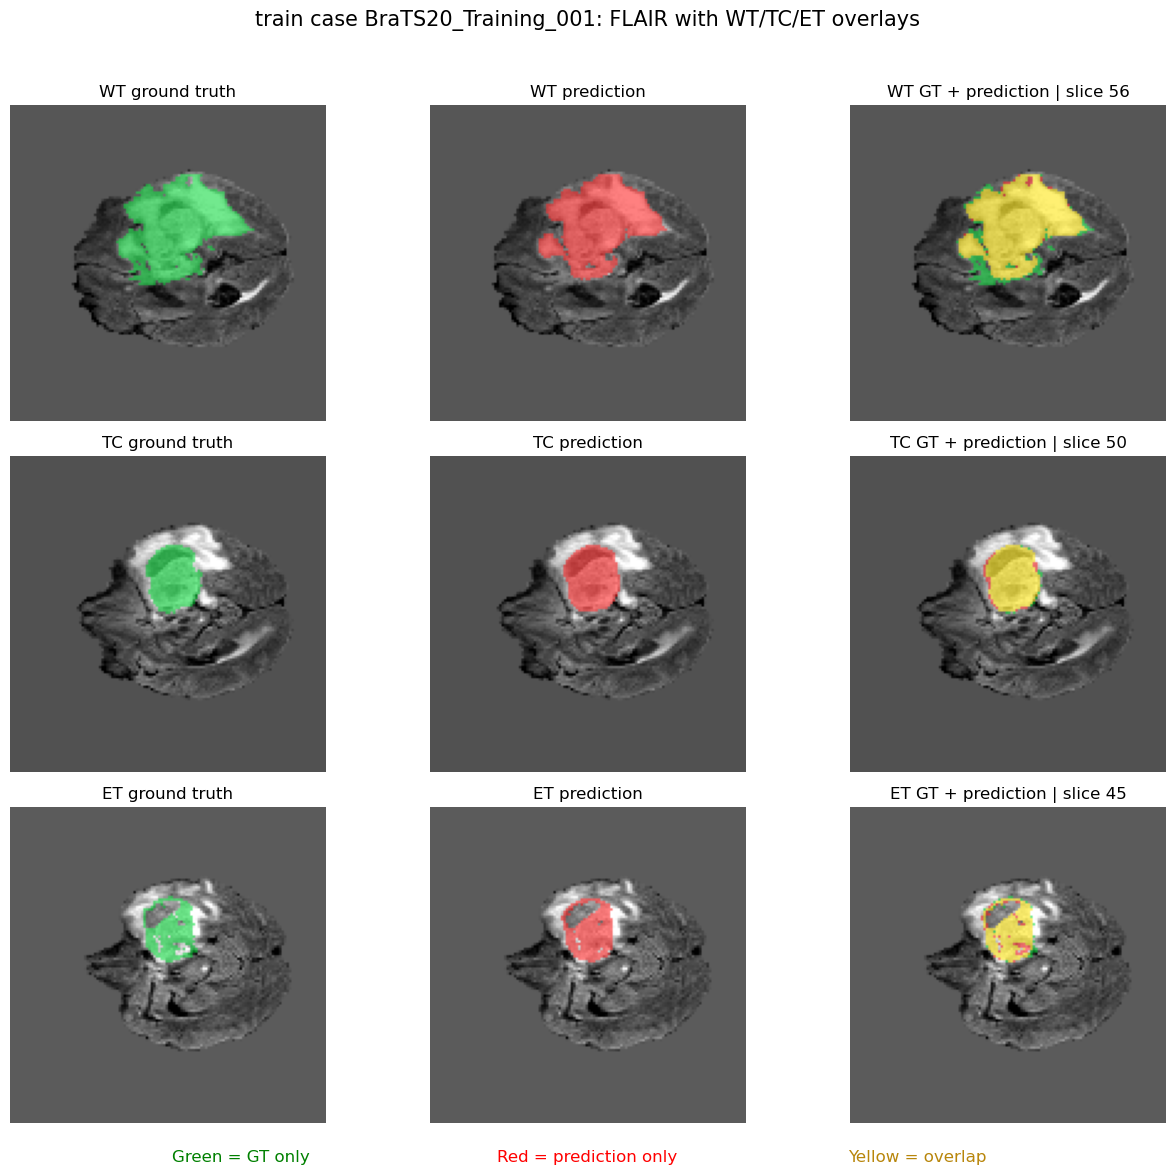

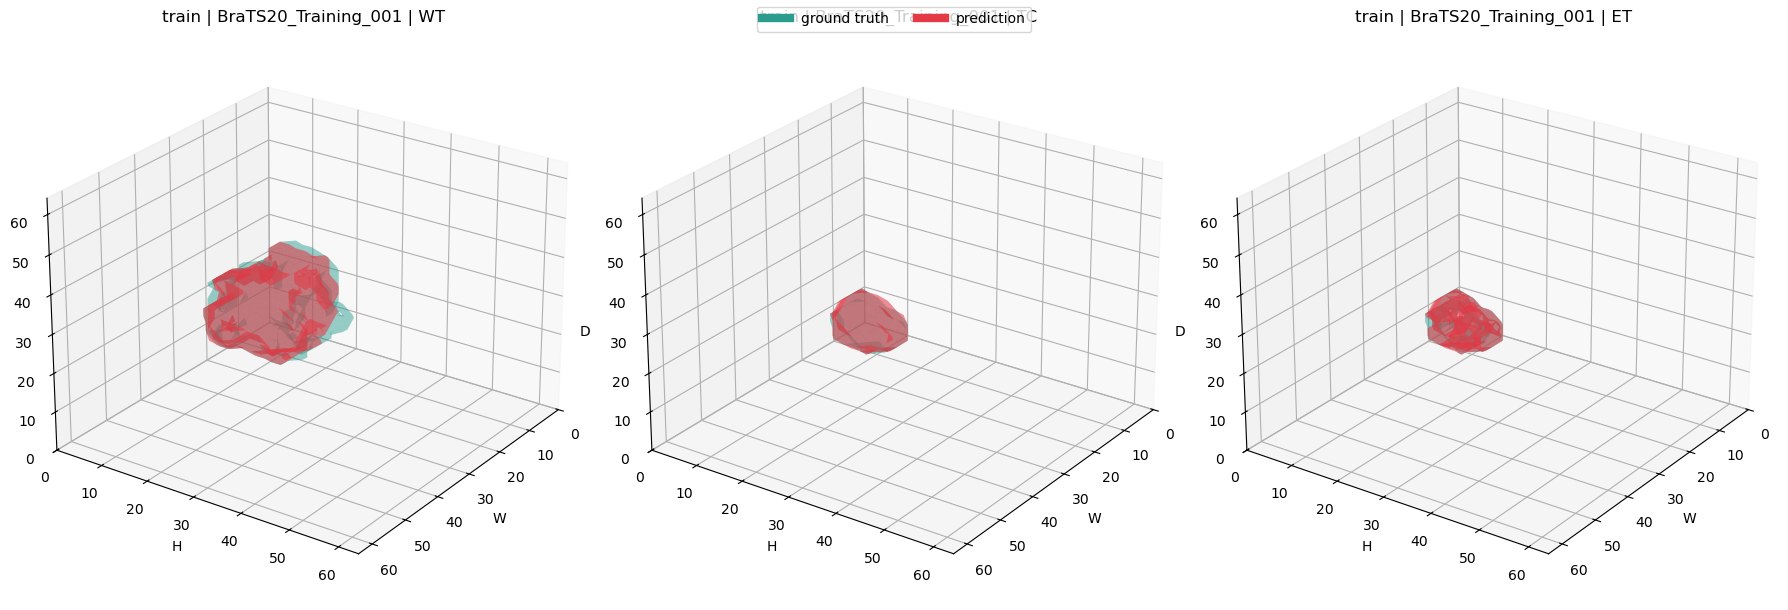

In [11]:
# Block 11: Run combined inference for one train case, save full 3D mask, and show mask overlays on FLAIR.
TRAIN_EXAMPLE_INDEX = 0

train_row, train_image, train_target_masks, train_probabilities, train_prediction_masks = predict_and_save_case(
    train_df, 'train', TRAIN_EXAMPLE_INDEX
)

display(summarize_case_region_scores(train_target_masks, train_prediction_masks))
plot_brain_overlay_figure(train_image, train_target_masks, train_prediction_masks, train_row['case_id'], 'train', save=True)
plot_3d_region_comparison(train_target_masks, train_prediction_masks, train_row['case_id'], 'train', plot_downsample_factor=2)

## Block 12. Validation Case Brain Overlay and 3D Mask Prediction


Case: BraTS20_Training_002
Prediction saved: /home/danishzaheer/Deep_learning_project/predictions/paper3_ensemble_3d_masks/valid/BraTS20_Training_002_ensemble_prediction_128.nii.gz
Ground truth saved: /home/danishzaheer/Deep_learning_project/predictions/paper3_ensemble_3d_masks/valid/BraTS20_Training_002_ground_truth_128.nii.gz


,region,dice,precision,sensitivity,specificity,hd95_voxels
0,WT,0.870242,0.806053,0.945540,0.998282,2.828427
1,TC,0.901265,0.832302,0.982689,0.999650,1.414214
2,ET,0.823208,0.796122,0.852201,0.999834,1.000000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].


Saved paper overlay figure: /home/danishzaheer/Deep_learning_project/predictions/paper3_ensemble_3d_masks/valid/BraTS20_Training_002_paper_overlay.png


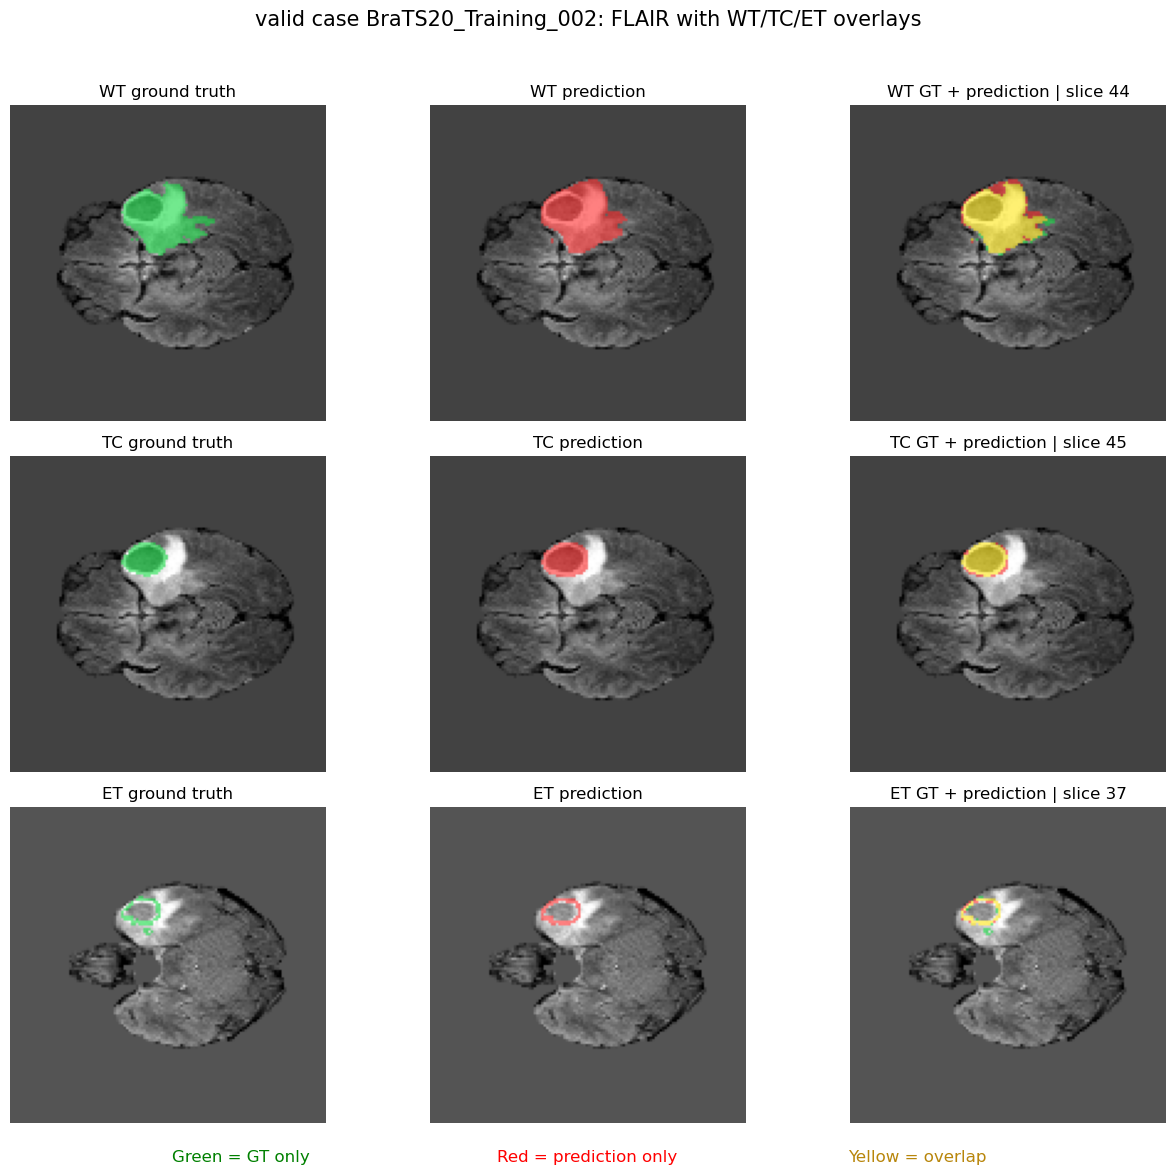

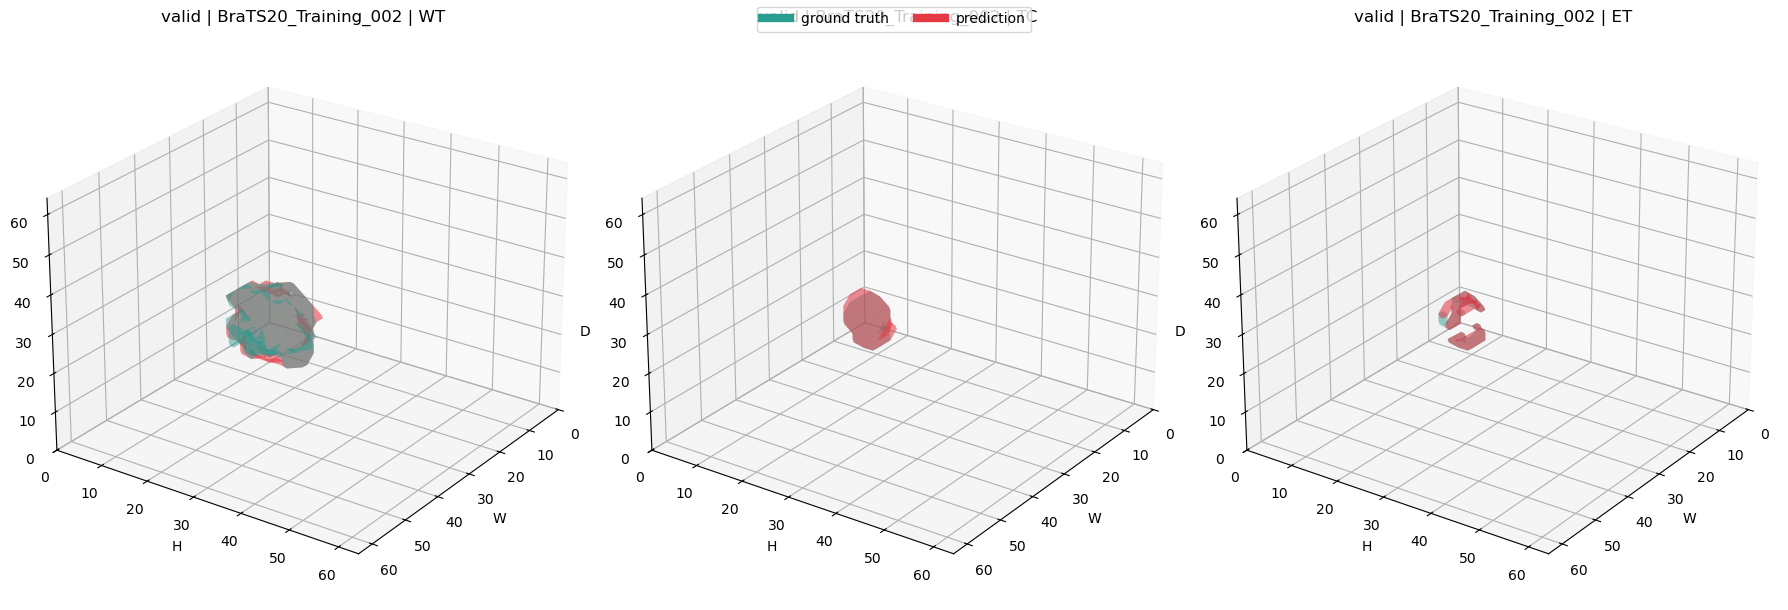

In [12]:
# Block 12: Run combined inference for one validation case, save full 3D mask, and show mask overlays on FLAIR.
VALID_EXAMPLE_INDEX = 0

valid_row, valid_image, valid_target_masks, valid_probabilities, valid_prediction_masks = predict_and_save_case(
    valid_df, 'valid', VALID_EXAMPLE_INDEX
)

display(summarize_case_region_scores(valid_target_masks, valid_prediction_masks))
plot_brain_overlay_figure(valid_image, valid_target_masks, valid_prediction_masks, valid_row['case_id'], 'valid', save=True)
plot_3d_region_comparison(valid_target_masks, valid_prediction_masks, valid_row['case_id'], 'valid', plot_downsample_factor=2)

## Block 13. Test Case Brain Overlay and 3D Mask Prediction


Case: BraTS20_Training_007
Prediction saved: /home/danishzaheer/Deep_learning_project/predictions/paper3_ensemble_3d_masks/test/BraTS20_Training_007_ensemble_prediction_128.nii.gz
Ground truth saved: /home/danishzaheer/Deep_learning_project/predictions/paper3_ensemble_3d_masks/test/BraTS20_Training_007_ground_truth_128.nii.gz


,region,dice,precision,sensitivity,specificity,hd95_voxels
0,WT,0.901651,0.864503,0.942135,0.999340,1.414214
1,TC,0.925300,0.932766,0.917953,0.999928,1.414214
2,ET,0.869507,0.849707,0.890252,0.999890,1.000000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000000011920929].


Saved paper overlay figure: /home/danishzaheer/Deep_learning_project/predictions/paper3_ensemble_3d_masks/test/BraTS20_Training_007_paper_overlay.png


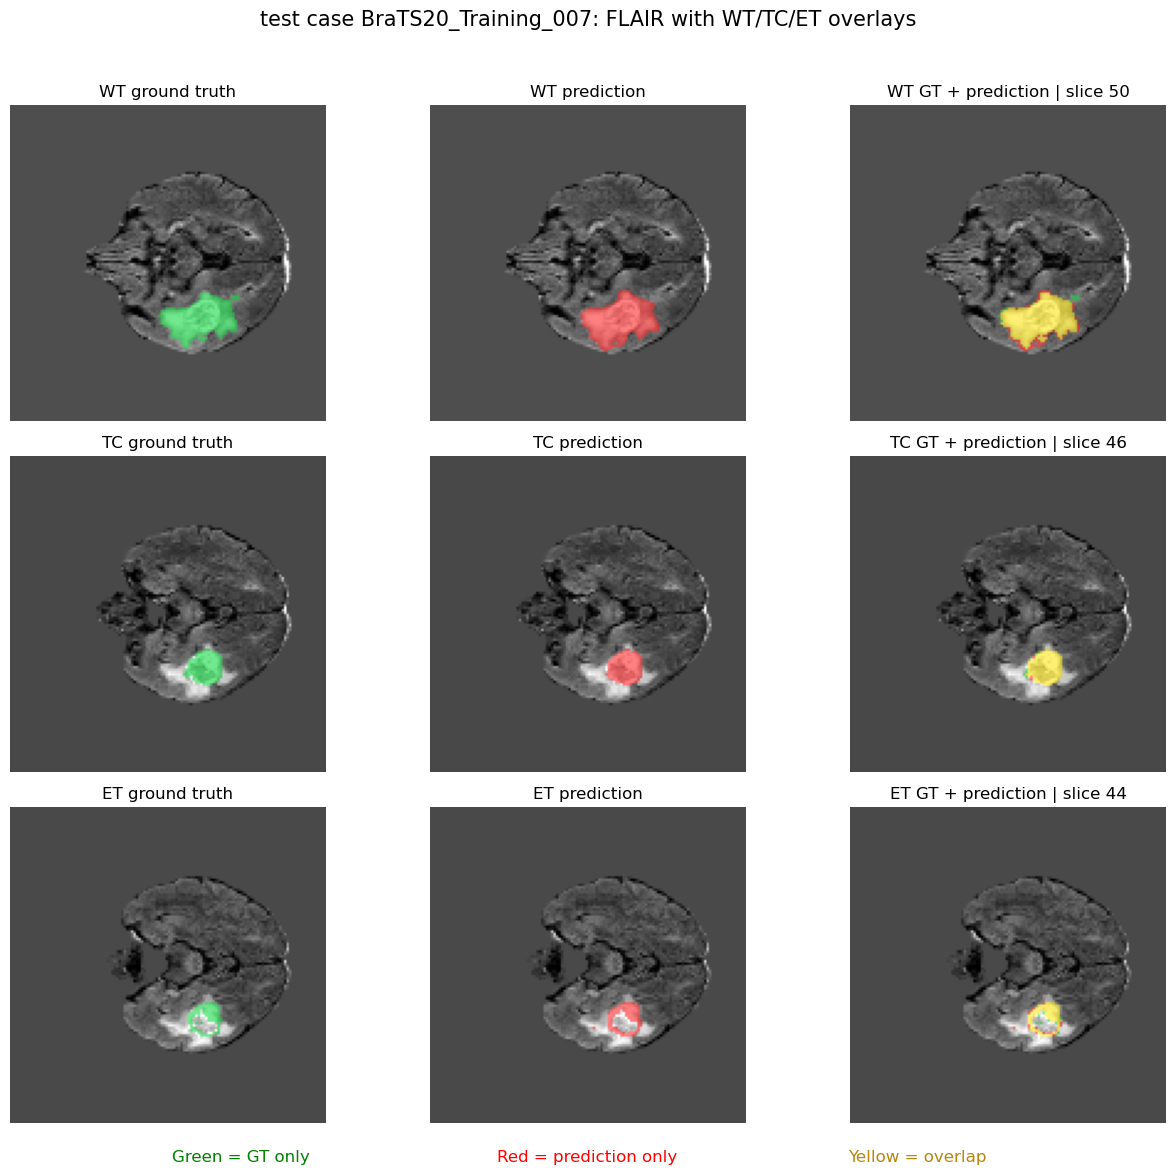

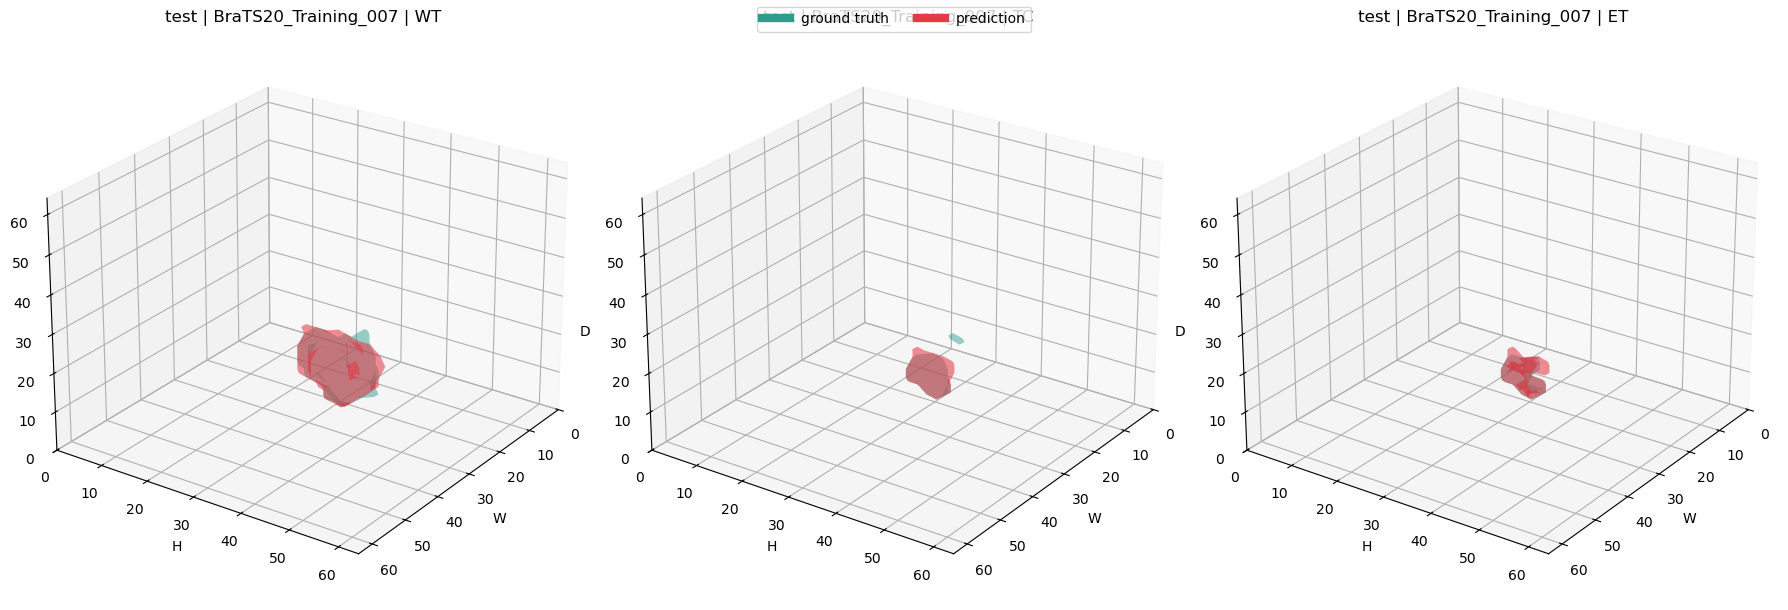

In [13]:
# Block 13: Run combined inference for one test case, save full 3D mask, and show mask overlays on FLAIR.
TEST_EXAMPLE_INDEX = 0

test_row, test_image, test_target_masks, test_probabilities, test_prediction_masks = predict_and_save_case(
    test_df, 'test', TEST_EXAMPLE_INDEX
)

display(summarize_case_region_scores(test_target_masks, test_prediction_masks))
plot_brain_overlay_figure(test_image, test_target_masks, test_prediction_masks, test_row['case_id'], 'test', save=True)
plot_3d_region_comparison(test_target_masks, test_prediction_masks, test_row['case_id'], 'test', plot_downsample_factor=2)